## Section 1 Figures

This notebook compiles the plots to make section 1. To store the plots in a different directory, specify `PAPER_FIGURES_ROOT` to your target path.

In [21]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator
from mocpy import MOC
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack
from pathlib import Path

import src.statistics.corrfiles as cf
import src.analysis.plots as plots

DESI_ROOT_DR2 = Path('/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP')
PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)
moc_list = sorted([
    Path(
        '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/', 
        f'hsc_moc{i+1}.fits'
    )
    for i in range(0, 4)
])
cmap_hsc = plt.get_cmap('plasma')
cmap_desi = plt.get_cmap('viridis')

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [22]:
hsc_bins = np.arange(0.3, 1.8, 0.3)
hsc = fio.FITS(str(Path(cf.fetch_hsc_files()).with_suffix('')) + '_withflags.fits')[1].read()

desi_tgts = [
    Path(DESI_ROOT_DR2, f'{tgt}_clustering.dat.fits') 
    for tgt in ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
    ]
desi_tbls = []
for desi_cat in desi_tgts:
    dt = Table(fio.read(desi_cat, columns=['RA', 'DEC', 'Z']))
    desi_tbls.append(dt)
desi = vstack(desi_tbls)
photoz = hsc['dnnz_photoz_best']
zbin = hsc['z_bin']

In [23]:
coords_desi = SkyCoord(
    ra=desi['RA'] * u.deg, 
    dec=desi['DEC'] * u.deg, 
    frame='icrs'
)
tbl_in_moc_n = [
    np.zeros(len(t), dtype=bool) for t in desi_tbls
]
desi_in_moc_n = np.zeros(len(desi), dtype=bool)
for i, mocf in enumerate(moc_list):
    print(f'Processing MOC file: {mocf}')
    moc = MOC.from_fits(mocf)
    desi_in_moc_n |= moc.contains_skycoords(coords_desi)
    for tind, t in enumerate(desi_tbls):
        tbl_in_moc_n[tind] |= moc.contains_skycoords(
            SkyCoord(ra=t['RA'] * u.deg, dec=t['DEC'] * u.deg, frame='icrs')
        )
desi_in_moc = desi[
    np.flatnonzero(desi_in_moc_n)
    ]
tbls_in_moc = [
    t[np.flatnonzero(tbl_in_moc_n[i])] 
    for i, t in enumerate(desi_tbls)
]

Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc2.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc2.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc3.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc3.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc4.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc4.fits


In [ ]:
# Calculate total survey area from MOC files
total_area_sr = 0.0  # in steradians
for mocf in moc_list:
    moc = MOC.from_fits(mocf)
    total_area_sr += moc.sky_fraction * 4 * np.pi  # convert from sky fraction to steradians

# Convert to square degrees
total_area_deg2 = total_area_sr * (180/np.pi)**2
print(f"Total survey area: {total_area_deg2:.2f} square degrees")

Total survey area: 455.45 square degrees


In [ ]:


with pm.make_plot('density_z', figsize=(9, 3.8), show=True) as (fig, ax):
    global_bins = np.linspace(0, np.nanmax(photoz), 500) 
    quality_mask = (
        ((hsc['dnnz_photoz_err95_max'] - hsc['dnnz_photoz_err95_min']) < 2.7)
        & ((hsc['mizuki_photoz_err95_max'] - hsc['mizuki_photoz_err95_max']) < 2.7)
    )

    for i, z in enumerate(hsc_bins[:-1]):
        z_mask = (photoz >= z) & (photoz < hsc_bins[i + 1])
        counts, bins = np.histogram(photoz[z_mask], bins=global_bins)
        # Scale by survey area
        counts_per_area = counts / total_area_deg2
        ax.hist(
            bins[:-1], bins=bins, weights=counts_per_area,
            color=cmap_hsc(i / len(hsc_bins)), 
            label=(
                f'{z:.1f} < ' 
                + r'$z_{\mathrm{best}}^{\mathtt{DNNz}}$' 
                + r' $\leq$' 
                + f' {hsc_bins[i + 1]:.1f}'
            ),
            alpha=0.5
        )
        counts_zbin, _ = np.histogram(photoz[zbin == i + 1], bins=global_bins)
        counts_zbin_per_area = counts_zbin / total_area_deg2
        ax.hist(
            bins[:-1], bins=bins, weights=counts_zbin_per_area,
            color=cmap_hsc(i / len(hsc_bins)), 
            alpha=0.3
        )
    
    # Total histogram scaled by area
    counts_total, _ = np.histogram(photoz, bins=global_bins)
    counts_total_per_area = counts_total / total_area_deg2
    ax.hist(
        bins[:-1], bins=bins, weights=counts_total_per_area,
        color='black', 
        histtype='step', 
        linewidth=1, 
        linestyle='-'
    )
    
    # Quality cut histogram scaled by area
    shear_selection = (quality_mask & (photoz <= 0.3)) | (zbin > 0)
    counts, bins = np.histogram(photoz[shear_selection], bins=global_bins)
    counts_per_area = counts / total_area_deg2
    # avoid 0s in the histogram
    nonzero = np.where(counts > 0)[0]
    if len(nonzero) > 0:
        start = nonzero[0]
        end = nonzero[-1]
        ax.step(
            bins[start:end+1][:-1],
            counts_per_area[start:end],
            where='post',
            color='black',
            linestyle='--',
            linewidth=0.8,
            label='Quality cut'
        )
    
    # DESI histogram scaled by area
    counts_desi, _ = np.histogram(desi_in_moc['Z'], bins=global_bins)
    counts_desi_per_area = counts_desi / total_area_deg2
    ax.hist(
        bins[:-1], bins=bins, weights=counts_desi_per_area,
        color='red',
        label='DESI (in HSC)',
        histtype='step',
        linewidth=2,
        linestyle='-.'
    )
    
    # Individual DESI targets scaled by area
    targets = ['BGS', 'LRG', 'ELG', 'QSO']
    for i, t in enumerate(tbls_in_moc):
        counts_target, _ = np.histogram(t['Z'], bins=global_bins)
        counts_target_per_area = counts_target / total_area_deg2
        ax.hist(
            bins[:-1], bins=bins, weights=counts_target_per_area,
            color=cmap_desi(i / len(tbls_in_moc)), 
            label=f'{targets[i]}', 
            histtype='step', 
            linewidth=1.2
        )

    ax.set_yscale('log')
    ax.set_xlabel('Redshift', fontsize=16)
    ax.set_ylabel(r'N(z) [deg$^{-2}$]', fontsize=16)
    
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.grid(True)
    
    ax.legend(ncols=2, fontsize=10.5, loc='upper right')
    ax.set_xlim(0, 2.85)
    ax.set_ylim(1.2e2/total_area_deg2, 1e6/total_area_deg2)  # Scale y-limits too

(15.5, 25.5)

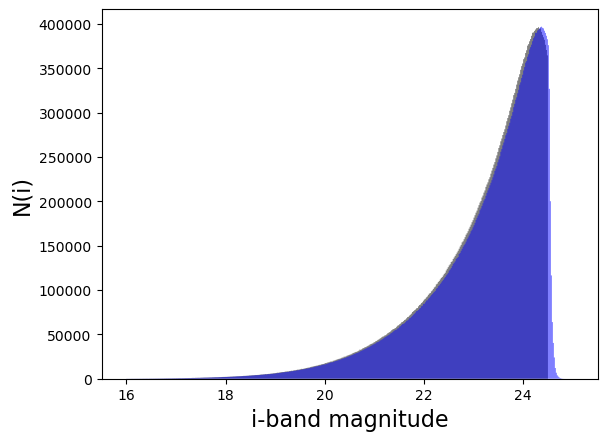

In [ ]:
imag_red = hsc['i_cm_mag'][:]
ai = hsc['a_i'][:]
imag = imag_red - ai

# Create i-band magnitude histogram using PlotManager
with pm.make_plot('i_band_magnitude', figsize=(8, 6)) as (fig, ax):
    ax.hist(
        imag, 
        bins=np.arange(16, 25, 0.02),
        color='black',
        histtype='stepfilled',
        linewidth=1.2,
        alpha=0.5,
        label='HSC i-band'
    )
    ax.hist(
        imag_red, 
        bins=np.arange(16, 25, 0.02),
        color='blue',
        histtype='stepfilled',
        linewidth=1.2,
        alpha=0.5,
        label='HSC i-band (redshifted)'
    )
    ax.set_xlabel('i-band magnitude', fontsize=16)
    ax.set_ylabel('N(i)', fontsize=16)
    ax.set_xlim(15.5, 25.5)
    ax.legend()

Processing z-bin 0
Number of objects in z-bin 0: 9146157
Processing z-bin 1
Number of objects in z-bin 1: 5889826
Processing z-bin 2
Number of objects in z-bin 2: 8445233
Processing z-bin 3
Number of objects in z-bin 3: 7023314
Processing z-bin 4
Number of objects in z-bin 4: 3902504
Processing z-bin 5
Number of objects in z-bin 5: 34407034


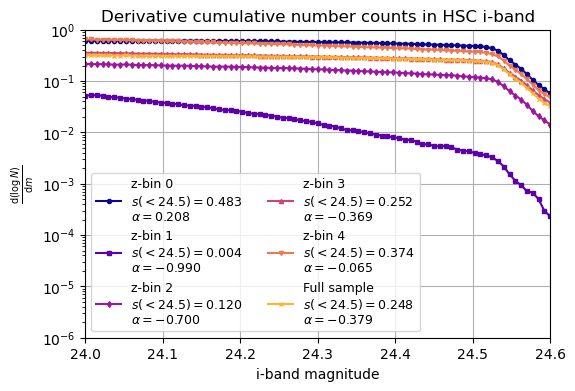

In [ ]:
mag_bins = np.linspace(24, 24.75, 101)
def cumulative_mag_counts(mag, ibmag):
    """Cumulative number counts for magnification bias."""
    return np.array([np.sum(ibmag < m) for m in mag])

# Create cumulative magnitude counts plot using PlotManager
with pm.make_plot('cumulative_mag_counts', figsize=(6, 4)) as (fig, ax):
    dmag = np.gradient(mag_bins)
    markers = ['o', 's', 'd', '^', 'v', 'x']
    for zbin_index in range(0, 6):
        print(f'Processing z-bin {zbin_index}')
        if zbin_index == 5:
            zbin = hsc
            imag = hsc['i_cm_mag'][:] #- hsc['a_i'][:]
        else:
            zbin = hsc[hsc["z_bin"] == zbin_index]
            imag = zbin['i_cm_mag'] #- zbin['a_i']
        print(f'Number of objects in z-bin {zbin_index}: {len(imag)}')
        mag_counts = cumulative_mag_counts(mag_bins, imag)
        dlog_counts = np.gradient(np.log10(mag_counts))
        derivative = dlog_counts / dmag
        s_interp = interp1d(mag_bins, derivative, bounds_error=False, fill_value='extrapolate')
        s_lim = s_interp(24.5)

        ax.plot(
            mag_bins, 
            derivative, 
            marker=markers[zbin_index],
            markersize=3, 
            label=(
                (f'z-bin {zbin_index}' if zbin_index < 5 else 'Full sample') +
                '\n' +
                rf'$s(< 24.5) = {s_lim:.3f}$' + 
                '\n' +
                rf'$\alpha = {2.5 * s_lim - 1:.3f}$'
            ),
            color=cmap_hsc(zbin_index/6),   
            )
    ax.grid(True)
    ax.set_xlabel('i-band magnitude')
    ax.set_ylabel(r'$\frac{\mathrm{d}(\log N)}{\mathrm{d}m}$')
    ax.set_yscale('log')
    ax.set_ylim(1e-6, 1)
    ax.set_xlim(24, 24.6)
    ax.set_title('Derivative cumulative number counts in HSC i-band')
    ax.legend(loc='lower left', fontsize=9, ncols=2)

Number of objects in z-bin 0: 9146157
Number of objects in z-bin 1: 5889826
Number of objects in z-bin 2: 8445233
Number of objects in z-bin 3: 7023314
Number of objects in z-bin 4: 3902504
Number of objects in z-bin 5: 34407034


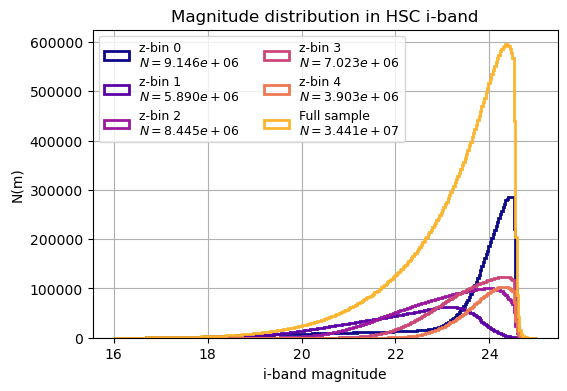

In [ ]:
## magnitude distributions for each z-bin
mag_bins_hist = np.linspace(16, 25, 301)

# Create magnitude distribution plot using PlotManager
with pm.make_plot('magnitude_distribution', figsize=(6, 4)) as (fig, ax):
    for zbin_index in range(0, 6):
        if zbin_index == 5:
            zbin = hsc
            imag = hsc['i_cm_mag'][:] - hsc['a_i'][:]
        else:
            zbin = hsc[hsc["z_bin"] == zbin_index]
            imag = zbin['i_cm_mag'][:] - zbin['a_i'][:]
        print(f'Number of objects in z-bin {zbin_index}: {len(imag)}')
        ax.hist(
            imag, 
            bins=mag_bins_hist, 
            histtype='step', 
            label=(
                (
                    f'z-bin {zbin_index}' 
                    if zbin_index < 5 
                    else 'Full sample'
                    )
                + '\n' +
                rf'$N = {len(imag):.3e}$'
            ),
            color=cmap_hsc(zbin_index/6), 
            linewidth=2
        )
    ax.grid(True)
    ax.set_xlabel('i-band magnitude')
    ax.set_ylabel('N(m)')
    ax.set_title('Magnitude distribution in HSC i-band')
    ax.legend(loc='upper left', fontsize=9, ncols=2)